In [ ]:
import torch
torch.cuda.is_available()


True

In [ ]:
!pip install ultralytics


In [ ]:
from google.colab import files
files.upload()


In [ ]:
!unzip plastic_detection.v3i.yolov8.zip

Archive:  plastic_detection.v3i.yolov8.zip
  inflating: README.dataset.txt      
  inflating: README.roboflow.txt     
  inflating: data.yaml               
   creating: test/
   creating: test/images/
 extracting: test/images/WIN_20260213_14_10_07_Pro_jpg.rf.815feb8a6e14eb88d8ac0de065090225.jpg  
 extracting: test/images/WIN_20260213_14_18_25_Pro_jpg.rf.8c570bf0ae0e67d0d42dc7638b41bb1d.jpg  
 extracting: test/images/WIN_20260213_14_18_33_Pro_jpg.rf.6efa8ae05b56187eefd10a42adab021f.jpg  
 extracting: test/images/WIN_20260213_14_18_46_Pro-2-_jpg.rf.81ee963285c9530eebb2aea144ab2e93.jpg  
 extracting: test/images/WIN_20260213_14_18_48_Pro_jpg.rf.d80ece2138b37d68ed390c94713ef19a.jpg  
 extracting: test/images/WIN_20260213_14_18_51_Pro_jpg.rf.c419cb494ab73b76de3c2a05ece52205.jpg  
 extracting: test/images/WIN_20260213_14_18_59_Pro-2-_jpg.rf.a61225f01cf45e760e4ad4ce626b4b94.jpg  
 extracting: test/images/WIN_20260213_14_19_02_Pro_jpg.rf.6e017fcb69c0c79a469e1ca3185d037c.jpg  
 extracting: tes

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")   # or yolov8s.pt, yolov8m.pt, etc.

model.train(
    data="data.yaml",
    epochs=50,
    imgsz=640
)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, po

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cd0cc102240>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
#files in the data.yaml


In [10]:
!cat data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['normal', 'plastic', 'plastic-normal-organic']

roboflow:
  workspace: cmd01
  project: plastic_detection-ngq2k
  version: 3
  license: CC BY 4.0
  url: https://universe.roboflow.com/cmd01/plastic_detection-ngq2k/dataset/3


image 1/1 /content/test/images/WIN_20260213_14_18_25_Pro_jpg.rf.8c570bf0ae0e67d0d42dc7638b41bb1d.jpg: 640x640 13 plastics, 8.4ms
Speed: 2.5ms preprocess, 8.4ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict4


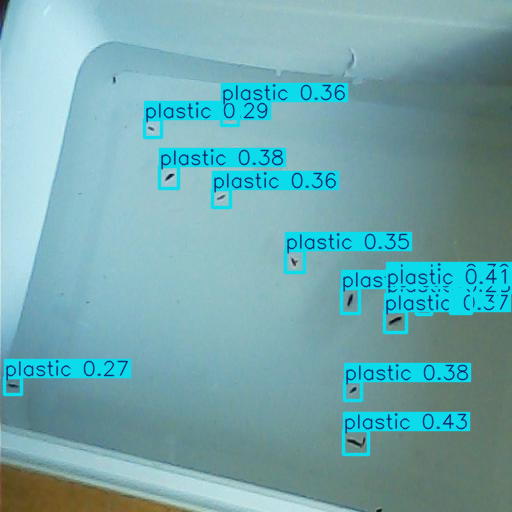

In [12]:
from ultralytics import YOLO
from PIL import Image
from IPython.display import display

# Load the trained model
model = YOLO('/content/runs/detect/train3/weights/best.pt')

# Perform inference on a test image with a lower confidence threshold
results = model.predict(source='test/images/WIN_20260213_14_18_25_Pro_jpg.rf.8c570bf0ae0e67d0d42dc7638b41bb1d.jpg', save=True, conf=0.25) # Lowered confidence from 0.5 to 0.25

# Display the results (this will show bounding boxes on the image)
for r in results:
    im_array = r.plot()  # plot a BGR numpy array of predictions
    im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image
    display(im)

In [ ]:
#save the yolo model as file



In [14]:
from ultralytics import YOLO

# Load the trained model
model = YOLO('/content/runs/detect/train3/weights/best.pt')

# Export the model to a file (e.g., as a PyTorch model)
# Other formats like 'onnx', 'torchscript', 'saved_model' are also available
model.export(format='torchscript', name='yolov8n_custom.pt')

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/train3/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (6.0 MB)

TorchScript: starting export with torch 2.9.0+cu128...
TorchScript: export success ✅ 1.8s, saved as '/content/runs/detect/train3/weights/best.torchscript' (11.9 MB)

Export complete (2.2s)
Results saved to /content/runs/detect/train3/weights
Predict:         yolo predict task=detect model=/content/runs/detect/train3/weights/best.torchscript imgsz=640 
Validate:        yolo val task=detect model=/content/runs/detect/train3/weights/best.torchscript imgsz=640 data=data.yaml  
Visualize:       https://netron.app


'/content/runs/detect/train3/weights/best.torchscript'

In [15]:
from google.colab import files

# The path to the exported model file
model_path = '/content/runs/detect/train3/weights/best.torchscript'

# Download the file
files.download(model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>